# Business Understanding

## Project Domain : Prediksi nilai matematika siswa berdasarkan karakteristik sosial dan akademik.

## Problem Statements : Bagaimana memprediksi skor matematika siswa dari data demografi dan persiapan akademik?


## Goals : Membangun model ANN regresi dengan akurasi tinggi (R² ≥ 0.80)

## Solution Statements : Menggunakan ANN dengan fitur: gender, etnis, pendidikan orang tua, makan siang, persiapan ujian, dsb

## Business value: Sekolah dapat mengidentifikasi siswa yang berisiko mendapatkan nilai rendah.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"annajmreyhan","key":"fcca516b6dd86bd69421cf30f4a3c909"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d rkiattisak/student-performance-in-mathematics

Dataset URL: https://www.kaggle.com/datasets/rkiattisak/student-performance-in-mathematics
License(s): other
student-performance-in-mathematics.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!mkdir student-performance-in-mathematics
!unzip student-performance-in-mathematics.zip -d student-performance-in-mathematics
!ls student-performance-in-mathematics

mkdir: cannot create directory ‘student-performance-in-mathematics’: File exists
Archive:  student-performance-in-mathematics.zip
  inflating: student-performance-in-mathematics/exams.csv  
exams.csv  student-mat.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import joblib
import os

In [ ]:
df = pd.read_csv('/content/student-performance-in-mathematics.zip')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


## Exploratory Data Analysis

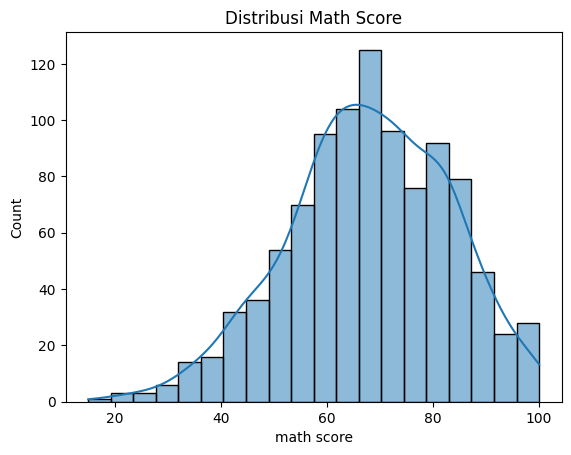

In [ ]:
sns.histplot(df['math score'], bins=20, kde=True)
plt.title("Distribusi Math Score")
plt.show()

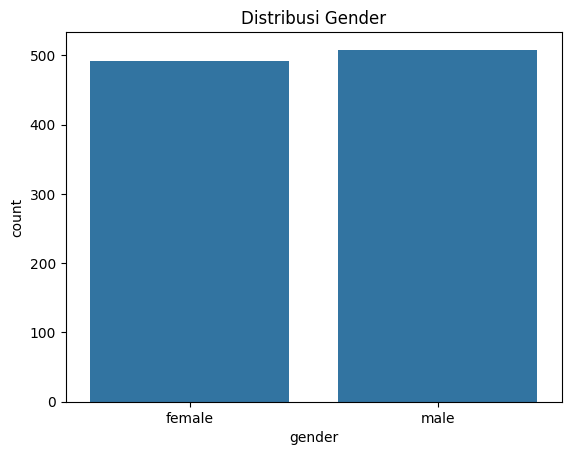

In [ ]:
sns.countplot(x='gender', data=df)
plt.title("Distribusi Gender")
plt.show()

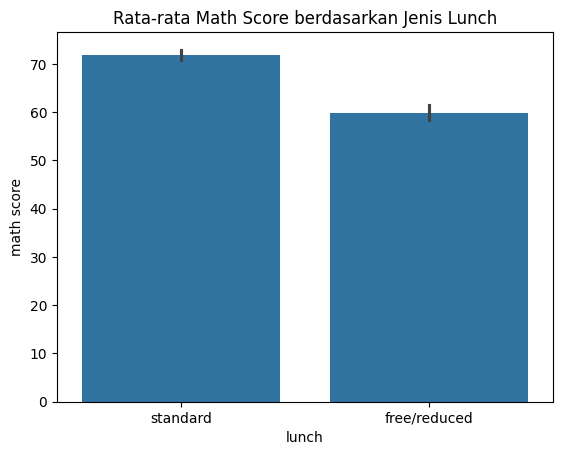

In [ ]:
sns.barplot(x='lunch', y='math score', data=df)
plt.title("Rata-rata Math Score berdasarkan Jenis Lunch")
plt.show()

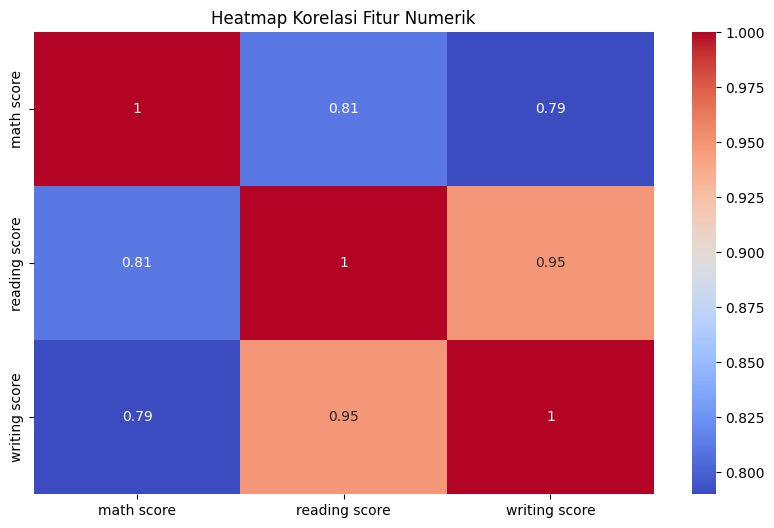

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()


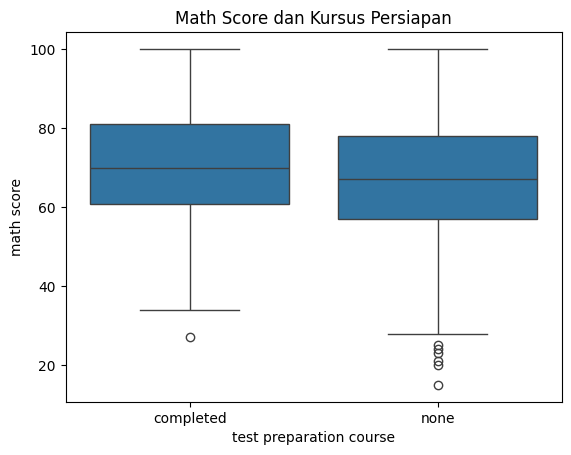

In [ ]:
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title("Math Score dan Kursus Persiapan")
plt.show()

# Data Preparation

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode semua fitur kategorikal
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Target: klasifikasi lulus (math score >=70)
X = df.drop('math score', axis=1)
y = df['math score'].apply(lambda x: 1 if x >= 70 else 0)

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Modeling

In [ ]:
import tensorflow as tf

# Membangun model ANN
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Kompilasi
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Pelatihan
model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4860 - loss: 0.7193 - val_accuracy: 0.7550 - val_loss: 0.5915
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8034 - loss: 0.5438 - val_accuracy: 0.8200 - val_loss: 0.4767
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8220 - loss: 0.4341 - val_accuracy: 0.8600 - val_loss: 0.3742
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8412 - loss: 0.3656 - val_accuracy: 0.8800 - val_loss: 0.3038
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8851 - loss: 0.2901 - val_accuracy: 0.9100 - val_loss: 0.2614
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8833 - loss: 0.2726 - val_accuracy: 0.8900 - val_loss: 0.2406
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8956 - loss: 0.2500 - val_accuracy: 0.8950 - val_loss: 0.2331
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8912 - loss: 0.2350 - val_accuracy: 0.8850 - val_loss: 0.2300
Ep

# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Evaluasi model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi Uji: {accuracy:.2f}")

# Prediksi dan metrik
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8845 - loss: 0.2417 
Akurasi Uji: 0.89
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Confusion Matrix:
[[86 12]
 [ 9 93]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        98
           1       0.89      0.91      0.90       102

    accuracy                           0.90       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.90      0.89       200



# Deployment

## Model Simulation

In [ ]:
# === 1. Buat ulang sample data ===
sample_data = {
    'gender': ['female'],
    'race/ethnicity': ['group B'],
    'parental level of education': ["bachelor's degree"],
    'lunch': ['standard'],
    'test preparation course': ['completed'],
    'reading score': [72],
    'writing score': [74]
}

sample_df = pd.DataFrame(sample_data)

# === 2. Encode kolom kategorikal dengan label encoder
for col in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
    sample_df[col] = label_encoders[col].transform(sample_df[col])

# === 3. Scaling
sample_scaled = scaler.transform(sample_df)

# === 4. Prediksi
prediction = model.predict(sample_scaled)
predicted_label = (prediction > 0.5).astype("int32")[0][0]

# === 5. Output
if predicted_label == 1:
    print("Prediksi: LULUS (math score >= 70)")
else:
    print("Prediksi: TIDAK LULUS (math score < 70)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediksi: TIDAK LULUS (math score < 70)


## Save Model

In [ ]:
# Simpan model ke format TensorFlow Lite
import os
import tensorflow as tf

# Buat folder jika belum ada
os.makedirs("model_output", exist_ok=True)

# Convert dan simpan TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model_output/model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpj48zsgo8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134211872784464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134211872800208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134211872797328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134211872786768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134211872785424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134211872787344: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
import joblib

# Simpan Standard Scaler
joblib.dump(scaler, "model_output/scaler.pkl")

# Simpan Label Encoders (dictionary)
joblib.dump(label_encoders, "model_output/label_encoder.pkl")

# Simpan dataset hasil encoding jika ingin digunakan kembali
joblib.dump(df, "model_output/dataset_encoded.pkl")

['model_output/dataset_encoded.pkl']

In [73]:
from google.colab import files
files.download("model_output/model.tflite")
files.download("model_output/scaler.pkl")
files.download("model_output/label_encoder.pkl")
files.download("model_output/dataset_encoded.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>